In [ ]:
# call the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
#load the data
df=pd.read_csv("mydata.csv")
df.head()

,x,y
0,1,1
1,2,2
2,2,3
3,1,4
4,3,3


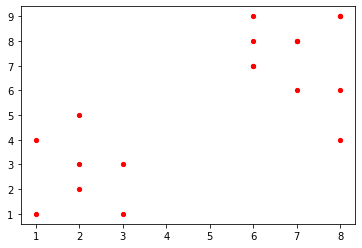

In [ ]:
#do a scatter plot with the red dots size 18
#from the data, x column values and y column values
plt.scatter(df['x'],df['y'],c='red', s=18)

In [ ]:
#for now, we say k is 2 (obvious from the above plot)
#k is the number of clusters that you want
#the search for optimal k value is addressed at the end of this algorithm
k=2

In [ ]:
#create a matrix containing all points
X=np.array(list(zip(df['x'],df['y'])))

In [ ]:
model=KMeans(n_clusters=k)

In [ ]:
#train the model using the fit() function
kmeans=model.fit(X)

In [ ]:
#To assign a label to all of the points, use the predict() function
labels=model.predict(X)

In [ ]:
#To get the centroids, use the cluster_centers property:
centroids=model.cluster_centers_

In [ ]:
#Print the clusters' labels and centroids
print(labels)
print(centroids)

[1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
[[7.         7.41666667]
 [2.         2.71428571]]


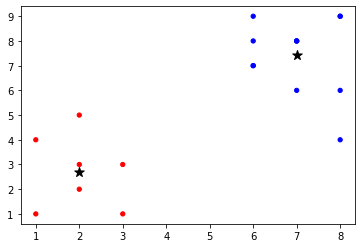

In [ ]:
#Plot the points and centroids on a scatter plot
#map the labels to colors
c=['blue','red','yellow','green']
colors=[c[i] for i in labels]

plt.scatter(df['x'],df['y'],c=colors, s=18)
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=100, c='black')

In [ ]:
#Using the model that you have just trained,
#you can use it to predict what cluster for any point

#making preductions
cluster=model.predict([[3,4]])[0]
print(c[cluster])

cluster=model.predict([[7,5]])[0]
print(c[cluster])

cluster=model.predict([[7,9]])[0]
print(c[cluster])


red
blue
blue


### So How do you determine the K value?

From above, we have used k value of 2. So how do you determine this? We need to use 'Silhouette Coefficient' in order to find the k value. Silhouette Coefficient is a measure of the quality of clustering. It measures cluster cohesion - the space between clusters. The range of values for the Silhouette Coefficient value is between -1 and 1 (1 is perfect match and -1 is perfect mismatch). To find the optimal k value, you have to identify the highest Silhouette Coefficient value that is closet to 1.

In [ ]:
#obtaining the silhouette coefficient(score)
from sklearn.metrics import silhouette_score

model=KMeans(n_clusters=2)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=2):  {silhouette_score(X,label)}')

silhouette Score (n=2):  0.6897112069939448


With the above result, try n_clusters value of 3 and see how the silhouette score changes. Remember that you use the k value that gives highest silhouette score toward 1. 3 gives a lower score, therefore 2 is the optimal k value with this data.